------------------------------------------------------------
Evaluación de métricas para el modelo de predicción de riesgo
------------------------------------------------------------

Contexto:
----------
Este script tiene como objetivo justificar la elección de métricas
para evaluar modelos que predicen el nivel de riesgo de proyectos.

En este problema, el costo de clasificar erróneamente un proyecto de
"alto riesgo" como "bajo riesgo" es muy alto. Por lo tanto, la prioridad
es detectar la mayor cantidad posible de proyectos realmente riesgosos,
incluso si eso implica generar algunas falsas alarmas.

Por esa razón, se prioriza el uso de las siguientes métricas:

1. **Recall (Sensibilidad):**
   - Mide qué proporción de los casos de "alto riesgo" fueron correctamente detectados.
   - Es la métrica principal, porque penaliza los falsos negativos.

2. **F1-score:**
   - Equilibra Precisión y Recall.
   - Útil cuando se busca un balance entre no generar demasiadas alarmas falsas
     y no dejar pasar riesgos reales.

3. **ROC-AUC:**
   - Evalúa la capacidad global del modelo para distinguir entre niveles de riesgo.
   - Permite comparar modelos independientemente del umbral de decisión.

4. **Precision:**
   - Secundaria: mide cuántos de los proyectos clasificados como "de alto riesgo"
     realmente lo son. Sirve para controlar que el modelo no genere demasiadas
     falsas alarmas.

5. **Accuracy:**
   - Se incluye solo como referencia global, pero **no es confiable**
     si las clases están desbalanceadas (por ejemplo, si hay pocos proyectos de alto riesgo).

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

--------------- Resultados de Evaluación ---------------
Accuracy:  0.499
Precision: 0.507
Recall:    0.499  <-- MÉTRICA PRINCIPAL
F1-score:  0.493

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.50      0.56       242
           1       0.46      0.64      0.54       419
           2       0.42      0.31      0.35       311
           3       0.57      0.50      0.53       228

    accuracy                           0.50      1200
   macro avg       0.52      0.49      0.50      1200
weighted avg       0.51      0.50      0.49      1200



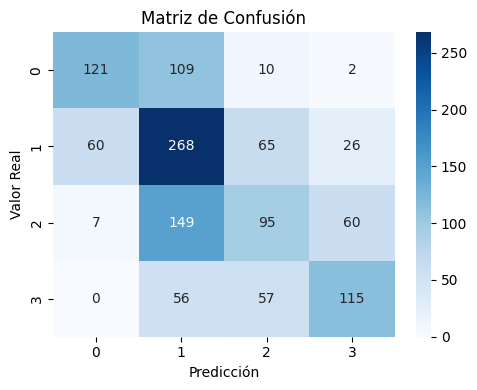

In [14]:
# Ruta base: carpeta donde está este script
BASE_DIR = Path().resolve()

# Ruta al dataset (sube un nivel y entra a 'src')
DATA_PATH = BASE_DIR.parent / "src" / "sel_all.csv"

# Leer el dataset
df = pd.read_csv(DATA_PATH)
X = df.drop("Risk_Level", axis=1)
y = df["Risk_Level"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenamiento de un modelo base
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Cálculo de métricas
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Impresión de resultados
print("--------------- Resultados de Evaluación ---------------")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}  <-- MÉTRICA PRINCIPAL")
print(f"F1-score:  {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# Visualizaciones
# ------------------------------------------------------------
# Matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

Conclusión:
-----------
- Se prioriza **Recall** como métrica principal, para maximizar la detección
  de proyectos realmente riesgosos.
- Se utiliza **F1-score** y **ROC-AUC** como métricas complementarias
  para balancear desempeño general.
- **Precision** y **Accuracy** sirven como referencia secundaria.

Este enfoque ayuda a minimizar la probabilidad de subestimar riesgos,
aun si eso implica un número mayor de falsas alarmas.